In [1]:
%load_ext autoreload
%autoreload 2

In [3]:
import argparse
import os
import sys
from huggingface_hub import hf_hub_download
from src.feature_generation import extract_feature, extract_encoder
from src.preprocessing import BioacousticDataset
import time
import numpy as np
from pathlib import Path

In [4]:
from src.augmented_mlp_training_new import load_encoder,run_cv_trials
from src.feature_generation import pool_features
from src.preprocessing import PipistrellePreprocessingPipeline,AudioCompose,TimeMasking,FrequencyMasking,TimeStretch,WaveformMixup
import pandas as pd
from pathlib import Path
import pickle

dir = Path("/idiap/temp/adeych/data")

encoder_name = "perch2"   # or "effnetb0" / "NLM_BEATs" -- everything else
                           # (pipeline, dataset, pooling, training loop)
                           # is encoder-agnostic and just follows this string

encoder = load_encoder(encoder_name, device="cuda")

if encoder_name == "perch2":
   target_sr = 32000 
   pipeline = PipistrellePreprocessingPipeline(target_sr=target_sr, expansion_factor=5,window_sec =5,overlap=0.5)
   X_bags_dir = "perch2-bags.pkl"
elif encoder_name == "effnetb0":
    target_sr = 16000
    pipeline = PipistrellePreprocessingPipeline(target_sr=target_sr, expansion_factor=10,window_sec =10,overlap=0.5)
    X_bags_dir = "effnetb0-bags.pkl"
elif encoder_name == "NLM_BEATs":
    target_sr = 16000
    pipeline = PipistrellePreprocessingPipeline(target_sr=target_sr, expansion_factor=10,window_sec =10,overlap=0.5)
    X_bags_dir = "NLM-bags.pkl"
else:
    raise ValueError(f"Unsupported encoder : {encoder_name}. Please choose from 'perch2', 'effnetb0', or 'NLM_BEATs'.")

augment_pipeline = AudioCompose([
    (TimeMasking(), 0.3),
    (FrequencyMasking(), 0.3),
    (TimeStretch(target_sr=target_sr), 0.3),
])

label_cols = ['type_a', 'type_b', 'type_c', 'type_d', 'echo']
clip_df = pd.read_csv(dir / "bat_metadata.csv")  # one row per clip, with relative_path column
root_dir = dir / "xenocanto-dataset"

print("Started loading features")
with open(dir / "feature_banks" / X_bags_dir, "rb") as f:
    X_bags = pickle.load(f)
print("Finished loading features")
window_level_list = pool_features(X_bags, windows=False,window_pooled=False,encoder = encoder_name)
clean_window_embeddings = dict(zip(clip_df['relative_path'], window_level_list))
X = pool_features(window_level_list,windows=True,encoder = encoder_name)

y = np.load(dir / "feature_banks" / "labels.npy")

#results_aug = run_cv_trials(
#    clip_df, clean_window_embeddings, X, y, root_dir,
#    encoder, encoder_name, pipeline, augment_pipeline,
#    label_cols, aug_prob=0.2, input_dim=X.shape[1],
#)
#results_noaug = run_cv_trials(
#    clip_df, clean_window_embeddings, X, y, root_dir,
#    encoder, encoder_name, pipeline, augment_pipeline,
#    label_cols, aug_prob=0.0, input_dim=X.shape[1],   # never loads audio or calls the encoder
#)

2026-08-19 18:05:31.859779558 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:700 operator()] No registered plugin EP device found for 'CUDAExecutionProvider' with device_id=0
2026-08-19 18:05:32.032618133 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 2 Memcpy nodes are added to the graph perch_v2 for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.


Started loading features
Finished loading features


In [ ]:
results_noaug = run_cv_trials(clip_df, clean_window_embeddings, X, y, root_dir,
                   encoder, encoder_name, pipeline, augment_pipeline,
                   label_cols, n_splits=5, num_trials=2, aug_prob=0.2,
                   use_oversampling = True, ovs_percentage = 0.2,
                   mixup_prob=0.3, mixup_alpha=0.2,epochs =10,
                   random_state=42, device="cuda")

Trial 1/3 (aug_prob=0.2, seed=42)
  fold 1/5
Final counts: [ 38  75 136  38 201]
[DEBUG Fold 1] Original train size: 227, Oversampled size: 261
[DEBUG Fold 1] train_df shape: (261, 7), y_train shape: (261, 5)
[DEBUG Fold 1] y_train sums: [ 38.  75. 136.  38. 201.]
[DEBUG] extract_feature called with model_name='perch2', window type=<class 'torch.Tensor'>
[DEBUG] total_windows = 89
[DEBUG MLP] clip_embs shape: torch.Size([16, 1536]) (Expected: [16, 1536])
[DEBUG MLP] labels shape: torch.Size([16, 5])
[DEBUG] extract_feature called with model_name='perch2', window type=<class 'torch.Tensor'>
[DEBUG] total_windows = 109
[DEBUG] extract_feature called with model_name='perch2', window type=<class 'torch.Tensor'>
[DEBUG] total_windows = 118
[DEBUG] extract_feature called with model_name='perch2', window type=<class 'torch.Tensor'>
[DEBUG] total_windows = 120
[DEBUG] extract_feature called with model_name='perch2', window type=<class 'torch.Tensor'>
[DEBUG] total_windows = 237
[DEBUG] extract

KeyboardInterrupt: 

2026-08-20 10:14:44.245397510 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:700 operator()] No registered plugin EP device found for 'CUDAExecutionProvider' with device_id=0
2026-08-20 10:14:44.371702268 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 2 Memcpy nodes are added to the graph perch_v2 for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.


Started loading features
Finished loading features
Trial 1/2 (aug_prob=0.0, seed=42)
  fold 1/5
Final counts: [ 38  75 136  38 201]
[DEBUG Fold 1] Original train size: 227, Oversampled size: 261
[DEBUG Fold 1] train_df shape: (261, 7), y_train shape: (261, 5)
[DEBUG Fold 1] y_train sums: [ 38.  75. 136.  38. 201.]
[DEBUG MLP] clip_embs shape: torch.Size([16, 1536]) (Expected: [16, 1536])
[DEBUG MLP] labels shape: torch.Size([16, 5])
    epoch 1/10 - loss 0.4890
    epoch 2/10 - loss 0.2801
    epoch 3/10 - loss 0.2054
    epoch 4/10 - loss 0.1766
    epoch 5/10 - loss 0.1518
    epoch 6/10 - loss 0.1397
    epoch 7/10 - loss 0.1137
    epoch 8/10 - loss 0.1025
    epoch 9/10 - loss 0.1032
    epoch 10/10 - loss 0.0704
  fold 2/5
Final counts: [ 38  67 130  38 204]
[DEBUG Fold 2] Original train size: 228, Oversampled size: 262
[DEBUG Fold 2] train_df shape: (262, 7), y_train shape: (262, 5)
[DEBUG Fold 2] y_train sums: [ 38.  67. 130.  38. 204.]
[DEBUG MLP] clip_embs shape: torch.Size([

/remote/idiap.svm/home.active/adeych/bat-project/src/plot_augmentation_comparison.py:148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(GROUP_ORDER, rotation=0, ha='center', fontsize=13)
/remote/idiap.svm/home.active/adeych/bat-project/src/plot_augmentation_comparison.py:148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(GROUP_ORDER, rotation=0, ha='center', fontsize=13)
/remote/idiap.svm/home.active/adeych/bat-project/src/plot_augmentation_comparison.py:148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(GROUP_ORDER, rotation=0, ha='center', fontsize=13)
/remote/idiap.svm/home

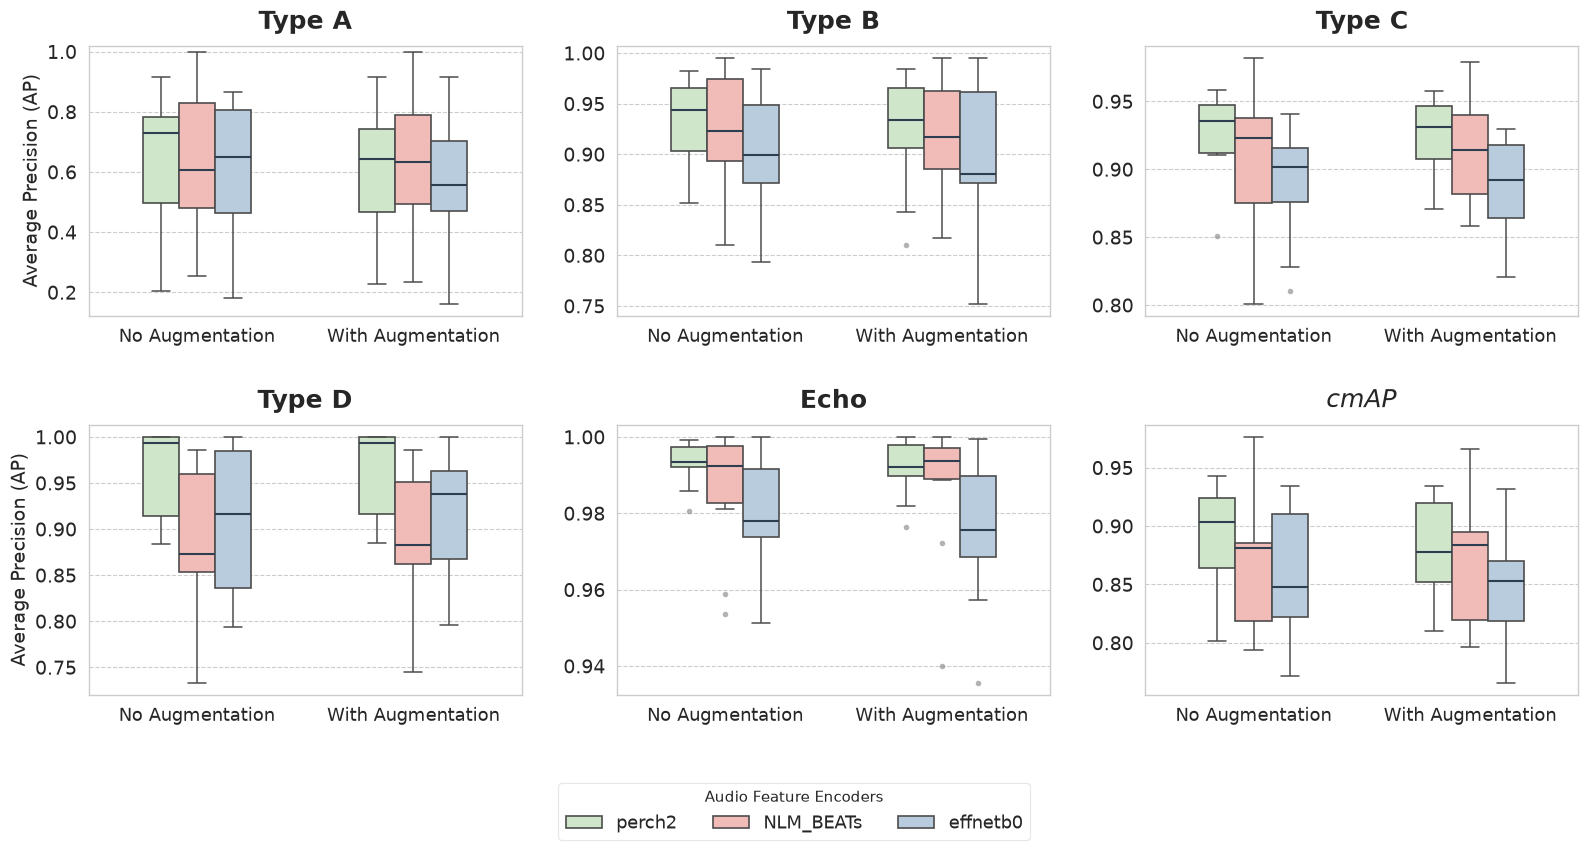

In [ ]:
from src.plot_augmentation_comparison import plot_augmentation_comparison_boxplots
from src.augmented_mlp_training_new import augmentation_experiment

import pickle

with open("/idiap/home/adeych/bat-project/results/mlp_NLM_BEATs_results1.pkl", "rb") as f:
    results_aug_NLM = pickle.load(f)
with open("/idiap/home/adeych/bat-project/results/mlp_effnetb0_results1.pkl", "rb") as f:
    results_aug_eff = pickle.load(f)
with open("/idiap/home/adeych/bat-project/results/mlp_perch2_results1.pkl", "rb") as f:
    results_aug_per = pickle.load(f)

results_no_aug = {
    'perch2' : augmentation_experiment(encoder_name = "perch2",augmentation = 0.0,epochs=20), 
    'NLM_BEATs' : augmentation_experiment(encoder_name = "NLM_BEATs",augmentation = 0.0,epochs=20), 
    'effnetb0' : augmentation_experiment(encoder_name = "effnetb0",augmentation = 0.0,epochs=20), 
}

results_aug = {
    'perch2' : results_aug_per, 
    'NLM_BEATs' : results_aug_NLM, 
    'effnetb0' : results_aug_eff, 
}

plot_augmentation_comparison_boxplots(results_no_aug, results_aug)

In [ ]:
from src.statistical_analysis_augmentation import  compare_encoders_overall,compare_augmentation_per_encoder
df_blocks = compare_encoders_overall(results_no_aug, results_aug)
df_aug_raw = compare_augmentation_per_encoder(results_no_aug, results_aug, correct=False)

=== Augmentation vs. No-Augmentation per encoder (Wilcoxon signed-rank) ===
Verdict column driven by raw (uncorrected) p-values at alpha=0.05. Both p_value and p_value_holm are shown below regardless.
  Encoder  N_blocks  Median_AP_no_aug  Median_AP_aug  Wilcoxon_stat  p_value  p_value_holm                   Verdict
NLM_BEATs        50            0.9298         0.9153       387.0000   0.2991        0.5981 No significant difference
 effnetb0        50            0.9014         0.8933       465.0000   0.4094        0.5981 No significant difference
   perch2        50            0.9457         0.9336       234.0000   0.0180        0.0540    No-augmentation better


2026-08-20 07:39:55.913294527 [W:onnxruntime:Default, onnxruntime_pybind_state.cc:700 operator()] No registered plugin EP device found for 'CUDAExecutionProvider' with device_id=0
2026-08-20 07:39:56.087956488 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 2 Memcpy nodes are added to the graph perch_v2 for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.


Started loading features
Finished loading features
Trial 1/2 (aug_prob=0.0, seed=42)
  fold 1/5
Final counts: [ 38  75 136  38 201]
[DEBUG Fold 1] Original train size: 227, Oversampled size: 261
[DEBUG Fold 1] train_df shape: (261, 7), y_train shape: (261, 5)
[DEBUG Fold 1] y_train sums: [ 38.  75. 136.  38. 201.]
[DEBUG MLP] clip_embs shape: torch.Size([16, 1536]) (Expected: [16, 1536])
[DEBUG MLP] labels shape: torch.Size([16, 5])
    epoch 1/10 - loss 0.4890
    epoch 2/10 - loss 0.2801
    epoch 3/10 - loss 0.2054
    epoch 4/10 - loss 0.1766
    epoch 5/10 - loss 0.1518
    epoch 6/10 - loss 0.1397
    epoch 7/10 - loss 0.1137
    epoch 8/10 - loss 0.1025
    epoch 9/10 - loss 0.1032
    epoch 10/10 - loss 0.0704
  fold 2/5
Final counts: [ 38  67 130  38 204]
[DEBUG Fold 2] Original train size: 228, Oversampled size: 262
[DEBUG Fold 2] train_df shape: (262, 7), y_train shape: (262, 5)
[DEBUG Fold 2] y_train sums: [ 38.  67. 130.  38. 204.]
[DEBUG MLP] clip_embs shape: torch.Size([

/remote/idiap.svm/home.active/adeych/bat-project/src/plot_augmentation_comparison.py:148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(GROUP_ORDER, rotation=0, ha='center', fontsize=13)
/remote/idiap.svm/home.active/adeych/bat-project/src/plot_augmentation_comparison.py:148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(GROUP_ORDER, rotation=0, ha='center', fontsize=13)
/remote/idiap.svm/home.active/adeych/bat-project/src/plot_augmentation_comparison.py:148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(GROUP_ORDER, rotation=0, ha='center', fontsize=13)
/remote/idiap.svm/home

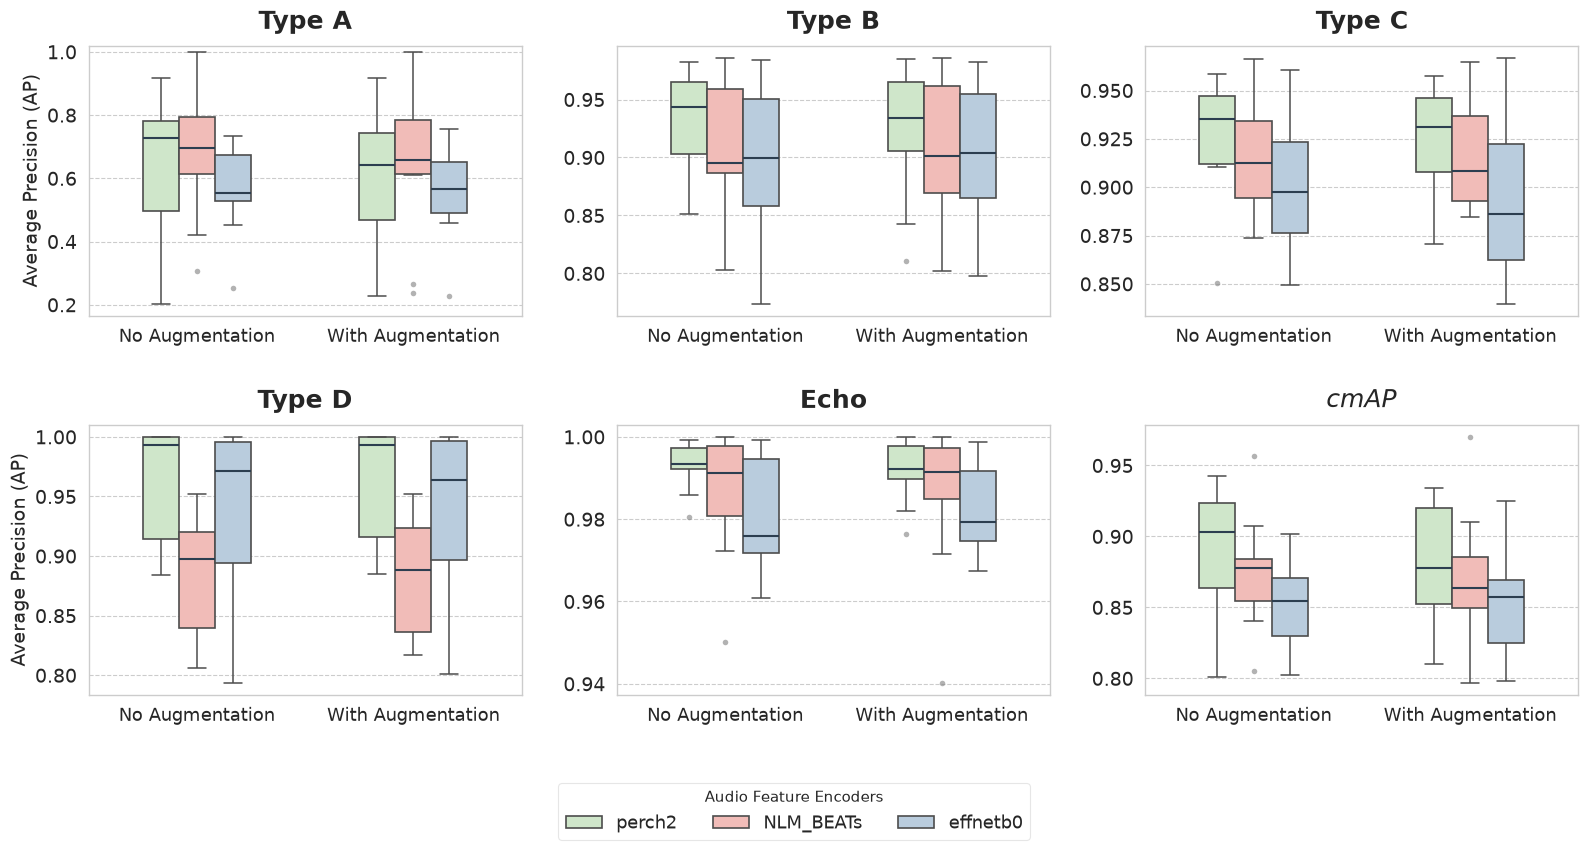

In [2]:
from src.plot_augmentation_comparison import plot_augmentation_comparison_boxplots
from src.augmented_mlp_training_new import augmentation_experiment

import pickle

with open("/idiap/home/adeych/bat-project/results/mlp_NLM_results0.pkl", "rb") as f:
    results_aug_NLM = pickle.load(f)
with open("/idiap/home/adeych/bat-project/results/mlp_eff_results0.pkl", "rb") as f:
    results_aug_eff = pickle.load(f)
with open("/idiap/home/adeych/bat-project/results/mlp_perch2_results0.pkl", "rb") as f:
    results_aug_per = pickle.load(f)

results_no_aug = {
    'perch2' : augmentation_experiment(encoder_name = "perch2",augmentation = 0.0,epochs=10), 
    'NLM_BEATs' : augmentation_experiment(encoder_name = "NLM_BEATs",augmentation = 0.0,epochs=10), 
    'effnetb0' : augmentation_experiment(encoder_name = "effnetb0",augmentation = 0.0,epochs=10), 
}

results_aug = {
    'perch2' : results_aug_per, 
    'NLM_BEATs' : results_aug_NLM, 
    'effnetb0' : results_aug_eff, 
}

plot_augmentation_comparison_boxplots(results_no_aug, results_aug)

=== Statistical Setup ===
Number of perfectly matched blocks (N): 100
Encoders compared: ['perch2', 'NLM_BEATs', 'effnetb0']

=== Friedman Test (encoders pooled across augmentation conditions) ===
Friedman chi^2 statistic: 42.0308
p-value: 7.4665e-10

Result: Significant difference detected (p < 0.05). Proceeding to Nemenyi post-hoc test.

=== Mean Ranks (Rank 1 = best) ===
  perch2: 1.575
  NLM_BEATs: 1.950
  effnetb0: 2.475

Best-ranked encoder overall: perch2

Nemenyi Critical Difference (CD): 0.4687

=== Nemenyi Pairwise p-value Matrix ===
              perch2  NLM_BEATs   effnetb0
perch2        1.0000     0.0218 5.8974e-10
NLM_BEATs     0.0218     1.0000 6.0163e-04
effnetb0  5.8974e-10 6.0163e-04     1.0000


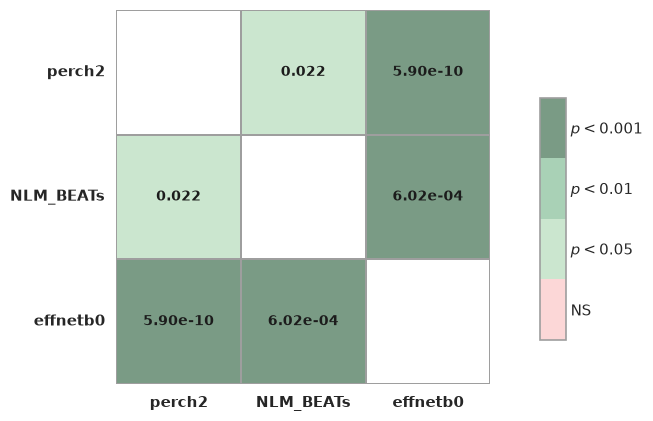

In [3]:
from src.statistical_analysis_augmentation import  compare_encoders_overall,compare_augmentation_per_encoder
df_blocks = compare_encoders_overall(results_no_aug, results_aug)

In [4]:
df_aug_raw = compare_augmentation_per_encoder(results_no_aug, results_aug, correct=False)

=== Augmentation vs. No-Augmentation per encoder (Wilcoxon signed-rank) ===
Verdict column driven by raw (uncorrected) p-values at alpha=0.05. Both p_value and p_value_holm are shown below regardless.
  Encoder  N_blocks  Median_AP_no_aug  Median_AP_aug  Wilcoxon_stat  p_value  p_value_holm                   Verdict
NLM_BEATs        50            0.9037         0.9041       363.0000   0.2685        0.5369 No significant difference
 effnetb0        50            0.9096         0.9144       555.0000   0.9241        0.9241 No significant difference
   perch2        50            0.9457         0.9336       234.0000   0.0180        0.0540    No-augmentation better


In [6]:
results_noaug = run_cv_trials(
    clip_df, clean_window_embeddings, X, y, root_dir,
    encoder, encoder_name, pipeline, augment_pipeline,
    label_cols, aug_prob=0.0, input_dim=X.shape[1],   # never loads audio or calls the encoder
)

Trial 1/5 (aug_prob=0.0, seed=42)
  fold 1/5
Final counts: [ 95 111 170  95 268]
[DEBUG Fold 1] Original train size: 227, Oversampled size: 375
[DEBUG Fold 1] train_df shape: (375, 7), y_train shape: (375, 5)
[DEBUG Fold 1] y_train sums: [ 95. 111. 170.  95. 268.]


TypeError: WaveformMixup.forward() missing 3 required positional arguments: 'label1', 'audio2', and 'label2'